<a href="https://colab.research.google.com/github/IdrisJunaidAI/ITAI_ML_FirstRepo_IdrisJunaid/blob/main/MT_IdrisJunaid_ITAI1371.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ITAI 1371: Introduction to Machine Learning Midterm Project

## Data Storytelling: An End to End ML Investigation

**Student:** Idris Junaid  
**Course:** ITAI 1371: Introduction to Machine Learning  
**Project Type:** Individual Midterm Project  
**Selected Dataset:** Titanic Survival Dataset  

### Project Goal

The goal of this notebook is to conduct a complete machine learning investigation using the Titanic dataset. The project follows the full machine learning workflow: data loading, exploratory data analysis, data preparation, feature engineering, model training, model evaluation, and final storytelling.

### Academic Integrity Note

The code cells are completed as a runnable technical scaffold. The reflection and conclusion sections include guided response spaces for the student to complete in their own words after reviewing the actual outputs from the notebook.


## Part 1: Choose Your Dataset

For this project, I selected the **Titanic Survival Dataset**. The classification target is `Survived`, where `0` means the passenger did not survive and `1` means the passenger survived.


In [1]:
import os
os.environ["MPLCONFIGDIR"] = "/tmp/matplotlib"
os.makedirs("/tmp/matplotlib", exist_ok=True)

import pandas as pd
import numpy as np

# Selected dataset: Titanic Survival Dataset
dataset_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

# Local fallback path used only when internet access is not available in the execution environment.
# In Google Colab, the URL above should load normally.
local_fallback_paths = [
    "/opt/pyvenv/lib/python3.13/site-packages/gradio/media_assets/data/titanic.csv",
    "/mnt/data/titanic.csv"
]

try:
    df = pd.read_csv(dataset_url)
    print(f"Successfully loaded dataset from: {dataset_url}")
except Exception as e:
    print(f"Could not load dataset from URL because: {e}")
    df = None
    for path in local_fallback_paths:
        if os.path.exists(path):
            df = pd.read_csv(path)
            print(f"Successfully loaded dataset from local fallback: {path}")
            break
    if df is None:
        raise FileNotFoundError("Dataset could not be loaded from the URL or from a local fallback path.")

print(f"Dataset shape: {df.shape}")


Successfully loaded dataset from: https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv
Dataset shape: (891, 12)


### Data Overview

The cell below displays the first five rows, the column names, a quick data type summary, and a basic missing value check.


In [2]:
print("First 5 rows:")
display(df.head())

print("Column names:")
print(df.columns.tolist())

print("Data types and non null counts:")
df.info()

print("Missing values by column:")
print(df.isnull().sum())

print("Target variable: Survived")
print("0 means did not survive")
print("1 means survived")


First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
Data types and non null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
Missing values by column:
PassengerId      0
Survived         0
Pclass           

## Part 2: Exploratory Data Analysis and Storytelling

The purpose of EDA is to understand the dataset before modeling. In this section, the visualizations focus on survival patterns by sex, passenger class, age, and fare.


### Visualization 1

This plot compares survival rate across passenger class and sex.


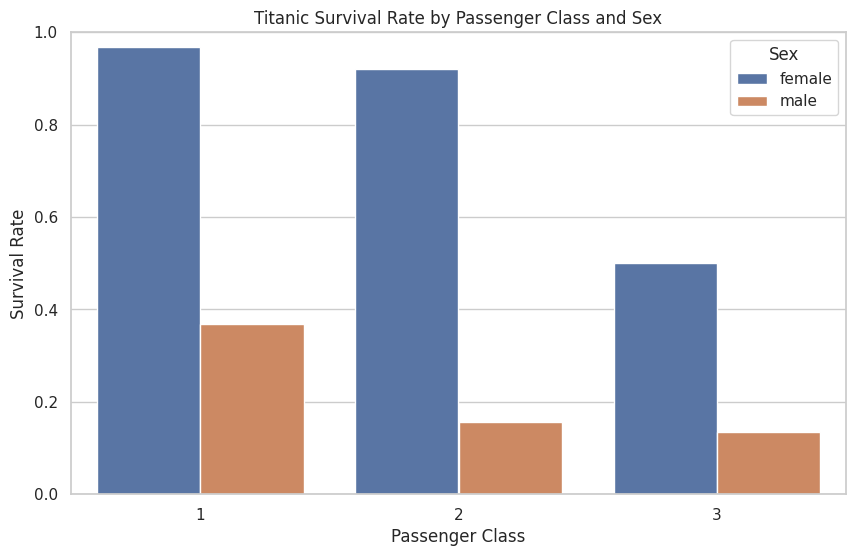

,Pclass,Sex,SurvivalRate
0,1,female,0.968085
1,1,male,0.368852
2,2,female,0.921053
3,2,male,0.157407
4,3,female,0.500000
5,3,male,0.135447


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

survival_summary = (
    df.groupby(["Pclass", "Sex"], as_index=False)["Survived"]
    .mean()
    .rename(columns={"Survived": "SurvivalRate"})
)

plt.figure(figsize=(10, 6))
sns.barplot(data=survival_summary, x="Pclass", y="SurvivalRate", hue="Sex")
plt.title("Titanic Survival Rate by Passenger Class and Sex")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.legend(title="Sex")
plt.show()

display(survival_summary)


### Visualization 2

This plot compares the age distribution of passengers who survived versus passengers who did not survive.


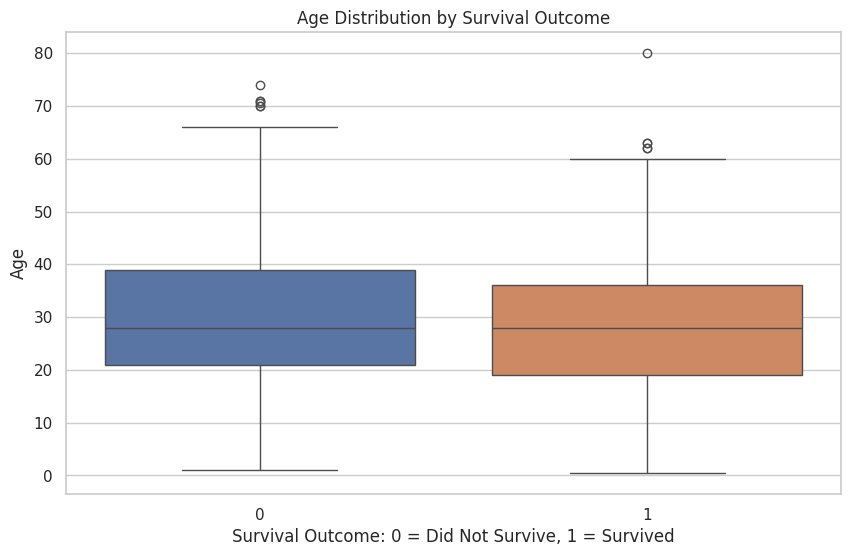

,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0,424.0,30.626179,14.172110,1.00,21.0,28.0,39.0,74.0
1,290.0,28.343690,14.950952,0.42,19.0,28.0,36.0,80.0


In [4]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Survived", y="Age", hue="Survived", legend=False)
plt.title("Age Distribution by Survival Outcome")
plt.xlabel("Survival Outcome: 0 = Did Not Survive, 1 = Survived")
plt.ylabel("Age")
plt.show()

age_summary = df.groupby("Survived")["Age"].describe()
display(age_summary)


### Additional EDA Check

This optional plot shows how fare varies by passenger class and survival outcome. It helps show whether economic position, represented by ticket fare and class, may have been connected to survival probability.


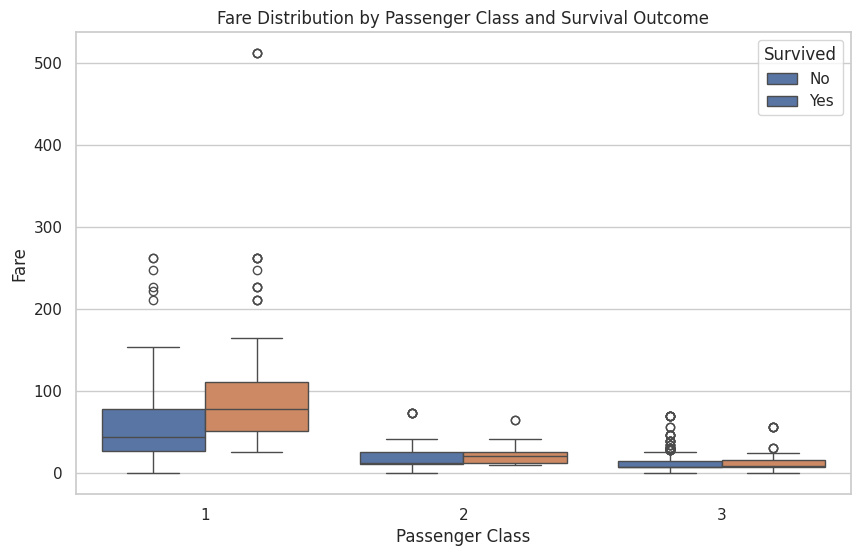

In [5]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Pclass", y="Fare", hue="Survived")
plt.title("Fare Distribution by Passenger Class and Survival Outcome")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.show()


### Interpretation of Your Visualizations

1. **What did you plot?**

In the first visualization, I plotted the survival rate by passenger class and sex. This allowed me to compare how survival outcomes changed across first, second, and third class passengers, while also separating the patterns for male and female passengers.

Also, in the second visualization, I plotted the distribution of age by survival outcome. This helped me examine whether passengers who survived and passengers who did not survive had noticeably different age patterns. I also added an additional fare visualization by passenger class and survival outcome to see how economic position may have been connected to survival.

2. **What story do your plots tell?**

The strongest story from the visualizations is that survival on the Titanic was not random. Sex and passenger class appear to have been major factors. Female passengers had a much higher survival rate than male passengers, especially in first and second class. First class passengers generally had better survival outcomes than third class passengers, which suggests that access, location on the ship, social priority, and economic status may have influenced who had the best chance of getting to safety.

The age plot suggests that age may have also contributed to survival, although the pattern is less direct than sex and class. Some younger passengers appear to have survived, which may connect to the historical idea of prioritizing women and children. However, the age distributions overlap, so age alone is not enough to explain survival. The fare plot supports the class based pattern because passengers who paid higher fares were more commonly connected with higher passenger class, and higher class groups generally had better survival rates.

3. **What is one hypothesis you can form based on your EDA?**

One hypothesis from the EDA is that a passenger was more likely to survive if the passenger was female, traveled in a higher passenger class, and paid a higher fare. A second related hypothesis is that sex may be the strongest individual predictor, while passenger class and fare add additional context about social and economic advantage. This hypothesis can be tested during modeling by checking whether features such as `sex_encoded`, `Pclass`, and `Fare` become important predictors.


## Part 3: Data Preparation and Feature Engineering

This section handles missing values, creates a few useful engineered features, and encodes categorical variables so the machine learning models can use the data.


In [6]:
print("Missing values before cleaning:")
print(df.isnull().sum())

# Fill missing Age values using the median because Age is numerical and may contain outliers.
age_median = df["Age"].median()
df["Age"] = df["Age"].fillna(age_median)

# Fill missing Embarked values using the mode because Embarked is categorical.
embarked_mode = df["Embarked"].mode()[0]
df["Embarked"] = df["Embarked"].fillna(embarked_mode)

# Cabin has many missing values, so instead of filling each cabin number,
# create an indicator showing whether cabin information was available.
df["CabinKnown"] = df["Cabin"].notna().astype(int)

# Feature engineering: family size and whether the passenger traveled alone.
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

print("Missing values after cleaning:")
print(df.isnull().sum())

print(f"Age median used for imputation: {age_median}")
print(f"Embarked mode used for imputation: {embarked_mode}")


Missing values before cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Missing values after cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
CabinKnown       0
FamilySize       0
IsAlone          0
dtype: int64
Age median used for imputation: 28.0
Embarked mode used for imputation: S


### Justification for Handling Missing Values

1. **Which feature did you choose?**

I chose the `Age` feature as the main feature for missing value handling because it is an important numerical variable and it had missing values in the dataset. Age is relevant to the survival story because younger passengers may have been treated differently during evacuation, and adult passengers may have faced different survival conditions.

2. **What method did you use to handle the missing values?**

I filled the missing `Age` values using the median age. I also filled the missing `Embarked` values using the mode because `Embarked` is a categorical feature. For `Cabin`, I did not try to fill in each missing cabin number because too many cabin values were missing. Instead, I created a new feature called `CabinKnown` to show whether cabin information was available.

3. **Why was this an appropriate method for this feature?**

Using the median was appropriate for `Age` because age is numerical and can be affected by unusual values or outliers. The median is more resistant to outliers than the mean, so it gives a stable central value without being pulled too strongly by very young or very old passengers. This allowed the model to keep rows that would otherwise be lost if missing ages were dropped.

Using the mode for `Embarked` was appropriate because it is categorical, so the most common category is a reasonable simple replacement. Creating `CabinKnown` was also appropriate because the missing cabin values may still contain useful information. Instead of pretending to know the actual cabin, the model can learn whether having cabin information recorded is connected to survival.


In [7]:
# Encode Sex as a binary numeric feature.
df["sex_encoded"] = df["Sex"].map({"female": 0, "male": 1})

print("Encoding example for Sex:")
display(df[["Sex", "sex_encoded"]].head())

# Encode Embarked using dummy variables because it has more than two categories.
df = pd.get_dummies(df, columns=["Embarked"], prefix="Embarked", drop_first=True, dtype=int)

print("Dataframe after categorical encoding and feature engineering:")
display(df.head())

print("Columns now available:")
print(df.columns.tolist())


Encoding example for Sex:


,Sex,sex_encoded
0,male,1
1,female,0
2,female,0
3,female,0
4,male,1


Dataframe after categorical encoding and feature engineering:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,CabinKnown,FamilySize,IsAlone,sex_encoded,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,0,2,0,1,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,1,2,0,0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0,1,1,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,1,2,0,0,0,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,0,1,1,1,0,1


Columns now available:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'CabinKnown', 'FamilySize', 'IsAlone', 'sex_encoded', 'Embarked_Q', 'Embarked_S']


### Justification for Encoding Categorical Features

1. **Which feature did you choose to encode?**

I encoded the `Sex` feature and the `Embarked` feature. These columns contain category labels, so they must be converted into numerical form before they can be used by machine learning models.

2. **What encoding method did you use?**

For `Sex`, I used a direct binary mapping where female was coded as `0` and male was coded as `1`. This works because the feature has two categories. For `Embarked`, I used one hot encoding with `pd.get_dummies()` because it has more than two categories. I used `drop_first=True` so the encoded columns would not contain unnecessary duplicate information.

3. **Why was this the right method? If you used `get_dummies`, why is `drop_first=True` often a good idea?**

The binary mapping was the right method for `Sex` because there were only two categories, so one numeric column could represent the information clearly. The model cannot directly process text labels like male and female, but it can process numeric values.

One hot encoding was the right method for `Embarked` because the port of embarkation is a nominal category. The ports do not have a natural ranking, so assigning values such as 0, 1, and 2 could incorrectly suggest an order. Dummy variables avoid that problem by creating separate indicator columns. Using `drop_first=True` is often helpful because one category can be represented when all the remaining dummy columns are zero. This reduces redundancy and helps prevent multicollinearity, especially for linear models such as Logistic Regression.


## Parts 4 and 5: Modeling and Evaluation

This section trains a Logistic Regression baseline and compares it with a Random Forest model. Logistic Regression is useful as a simple baseline. Random Forest can capture nonlinear relationships and interactions between features.


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

feature_cols = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "sex_encoded",
    "FamilySize",
    "IsAlone",
    "CabinKnown",
    "Embarked_Q",
    "Embarked_S"
]

target_col = "Survived"

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(f"Training set has {X_train.shape[0]} samples.")
print(f"Test set has {X_test.shape[0]} samples.")
print("Features used in the model:")
print(feature_cols)


Training set has 712 samples.
Test set has 179 samples.
Features used in the model:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'sex_encoded', 'FamilySize', 'IsAlone', 'CabinKnown', 'Embarked_Q', 'Embarked_S']


### Model 1: Logistic Regression Baseline

The Logistic Regression model is used as a baseline comparison model.


In [9]:
log_reg = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=42)
)

log_reg.fit(X_train, y_train)
y_pred_log_reg = log_reg.predict(X_test)
acc_log_reg = accuracy_score(y_test, y_pred_log_reg)

print(f"Baseline Model: Logistic Regression Test Accuracy: {acc_log_reg:.2%}")


Baseline Model: Logistic Regression Test Accuracy: 80.45%


### Model 2: Random Forest Classifier

The Random Forest model is selected because it can model nonlinear patterns and interactions, such as how passenger class, sex, fare, age, and family structure may work together to influence survival.


In [10]:
my_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=7,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

my_model.fit(X_train, y_train)
y_pred_my_model = my_model.predict(X_test)
acc_my_model = accuracy_score(y_test, y_pred_my_model)

print(f"Chosen Model: Random Forest Classifier Test Accuracy: {acc_my_model:.2%}")
print(f"Accuracy Difference: {(acc_my_model - acc_log_reg):.2%}")


Chosen Model: Random Forest Classifier Test Accuracy: 81.56%
Accuracy Difference: 1.12%


### Evaluation and Reflection

The next cell prints the classification report, confusion matrix, and feature importance values for the Random Forest model.


Classification Report for Random Forest Classifier:
                 precision    recall  f1-score   support

Did Not Survive       0.85      0.84      0.84       105
       Survived       0.77      0.78      0.78        74

       accuracy                           0.82       179
      macro avg       0.81      0.81      0.81       179
   weighted avg       0.82      0.82      0.82       179

Confusion Matrix:
[[88 17]
 [16 58]]


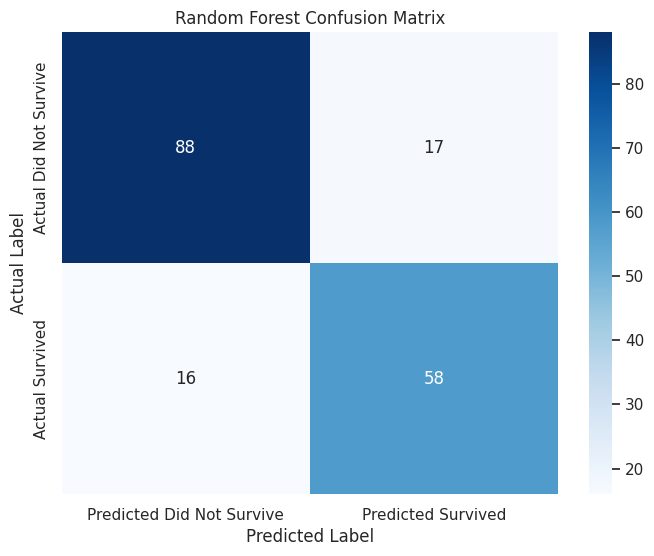

Random Forest Feature Importance:


,Feature,Importance
5,sex_encoded,0.385796
4,Fare,0.173093
1,Age,0.132936
0,Pclass,0.092971
8,CabinKnown,0.061695
6,FamilySize,0.061032
2,SibSp,0.029104
3,Parch,0.021943
10,Embarked_S,0.020917
7,IsAlone,0.011966


In [11]:
print("Classification Report for Random Forest Classifier:")
print(classification_report(y_test, y_pred_my_model, target_names=["Did Not Survive", "Survived"]))

cm = confusion_matrix(y_test, y_pred_my_model)
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Did Not Survive", "Predicted Survived"],
    yticklabels=["Actual Did Not Survive", "Actual Survived"]
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": my_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("Random Forest Feature Importance:")
display(importance_df)


### Reflection Questions

1. **Which model performed better, the baseline or yours? Was it a big difference?**

The Random Forest Classifier performed slightly better than the Logistic Regression baseline. The Logistic Regression model had a test accuracy of **80.45%**, while the Random Forest model had a test accuracy of **81.56%**. The improvement was about **1.12 percentage points**, so it was not a large difference.

This means the Random Forest model was better, but only slightly. The result suggests that the Titanic dataset has strong patterns that a simpler model can already capture fairly well. The Random Forest may have gained a small advantage because it can model nonlinear relationships and interactions, such as the combined effect of sex, class, fare, age, and family size.

2. **What are the precision and recall for the positive class, class 1?**

For the positive class, where `Survived = 1`, the Random Forest model had a precision of **0.77** and a recall of **0.78**.

3. **Interpret the precision and recall. In the context of the Titanic dataset, what do these numbers mean?**

The precision of **0.77** means that when the model predicted a passenger survived, it was correct about 77% of the time. In other words, some passengers were predicted as survivors even though they actually did not survive.

The recall of **0.78** means that the model correctly identified about 78% of the passengers who actually survived. In the confusion matrix, the model correctly predicted **58 survivors** and missed **16 actual survivors**. This shows that the model did a reasonably good job identifying survivors, but it still failed to capture some survival cases.

4. **Which error is more costly for this dataset, a False Positive or a False Negative? Explain your reasoning.**

For this Titanic survival project, a False Negative can be considered more costly from a human interpretation standpoint. A False Negative means the model predicted that a passenger did not survive when the passenger actually survived. This is costly because the model fails to recognize a real survivor and misses a pattern that could explain survival.

However, the cost depends on the purpose of the model. If this were a historical analysis, both types of errors matter because each error distorts the survival story. A False Positive incorrectly gives survival to someone who did not survive, while a False Negative removes survival from someone who did survive. For a data storytelling project, I would focus on reducing False Negatives because identifying the conditions linked to actual survival is central to the investigation.


## Part 6: Conclusion: The Titanic Survival Data Story

**The goal of this project was to use the Titanic dataset to build an end to end machine learning investigation that predicts whether a passenger survived**. The target variable was `Survived`, and the project used EDA, data preparation, feature engineering, model training, and evaluation to tell a clear data story. The EDA showed that survival was strongly connected to passenger characteristics rather than being random. The most important visual pattern was that female passengers and higher class passengers had better survival outcomes. Age and fare also added useful context, but sex and passenger class appeared to carry the clearest survival signal.

The data preparation step helped make the dataset usable for machine learning. Missing `Age` values were filled with the median, missing `Embarked` values were filled with the mode, and the highly incomplete `Cabin` column was transformed into a more useful `CabinKnown` indicator. Feature engineering also added `FamilySize` and `IsAlone`, which allowed the models to consider whether traveling with family may have influenced survival. Categorical features such as `Sex` and `Embarked` were encoded into numerical form. These preparation choices were important because machine learning models require clean numerical input, and poor handling of missing or categorical data could weaken the results.

The Logistic Regression baseline achieved **80.45%** test accuracy, while the Random Forest Classifier achieved **81.56%** test accuracy. The Random Forest performed slightly better, but the difference was small. The classification report showed that the Random Forest had **0.77 precision** and **0.78 recall** for the survivor class. **The feature importance** table supported the EDA because `sex_encoded` was the most important feature, followed by `Fare`, `Age`, and `Pclass`. **A limitation of this model** is that the dataset is historical and relatively small, so the model may not fully capture every social, physical, or situational factor that affected survival. **A strong next step would be to tune the model further**, compare additional algorithms, and evaluate whether more advanced feature engineering can reduce false negatives while keeping the model interpretable as much as possible.
